Ref

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(''))

from db_connect import get_db_engine

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Đã import thư viện xong!")

Đã import thư viện xong!


Extract

In [ ]:

file_path = '../data/household_power_consumption.txt/household_power_consumption.txt'

print(f"Đang đọc file từ: {file_path}")

df_raw = pd.read_csv(file_path, sep=';', na_values=['?'], low_memory=False)

print(f"Số dòng dữ liệu gốc: {len(df_raw):,}")
print("5 dòng đầu tiên:")
display(df_raw.head())

Đang đọc file từ: ../data/household_power_consumption.txt/household_power_consumption.txt
Số dòng dữ liệu gốc: 2,075,259
5 dòng đầu tiên:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.000


Data audit

--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB

--- TỈ LỆ DỮ LIỆU THIẾU (%) ---
Global_active_power     1.252
Global_reactive_power   1.252
Voltage                 1.252
Global_intensity        1.252
Sub_metering_1          1.252
Sub_metering_2          1.252
Sub_metering_3          1.252
dtype: float64


C:\Users\giath\AppData\Local\Temp\ipykernel_5492\2196211572.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='Reds_r')


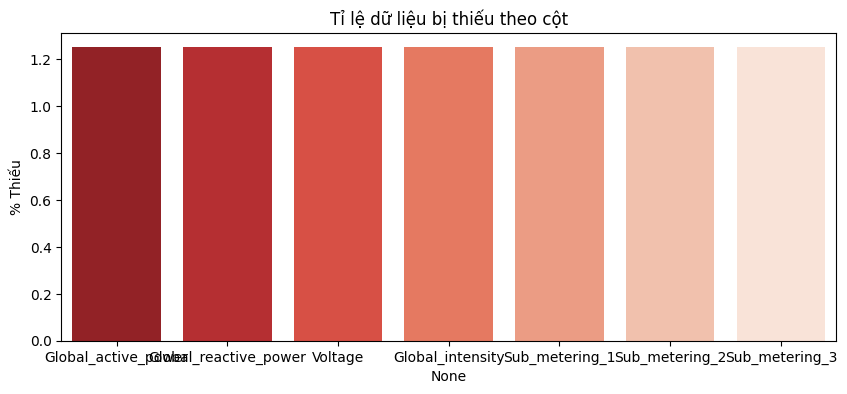

In [ ]:

print("--- THÔNG TIN DỮ LIỆU ---")
df_raw.info()

print("\n--- TỈ LỆ DỮ LIỆU THIẾU (%) ---")
missing_percent = df_raw.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

if not missing_percent.empty:
    print(missing_percent)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='Reds_r')
    plt.title("Tỉ lệ dữ liệu bị thiếu theo cột")
    plt.ylabel("% Thiếu")
    plt.show()
else:
    print("Tuyệt vời! Không có dữ liệu bị thiếu (NaN).")

In [ ]:
print("\n--- KIỂM TRA TRÙNG LẶP ---")
duplicate_count = df_raw.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn: {duplicate_count:,}")


print("\n--- THỐNG KÊ MÔ TẢ ---")
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
print(df_raw[numeric_cols].describe())

print("\n--- KIỂM TRA GIÁ TRỊ ÂM ---")
for col in numeric_cols:  
    if df_raw[col].dtype != 'object':
        negative_count = (df_raw[col] < 0).sum()
        if negative_count > 0:
            print(f"⚠️ Cột '{col}': {negative_count} giá trị âm")
        else:
            print(f"✅ Cột '{col}': Không có giá trị âm")


print("\n--- KIỂM TRA ĐỊNH DẠNG THỜI GIAN ---")
try:
    pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'], dayfirst=True, errors='raise')
    print("✅ Date và Time: Định dạng hợp lệ")
except Exception as e:
    print(f"⚠️ Lỗi định dạng thời gian: {e}")


--- KIỂM TRA TRÙNG LẶP ---
Số dòng trùng lặp hoàn toàn: 0

--- THỐNG KÊ MÔ TẢ ---
       Global_active_power  Global_reactive_power     Voltage  \
count          2049280.000            2049280.000 2049280.000   
mean                 1.092                  0.124     240.840   
std                  1.057                  0.113       3.240   
min                  0.076                  0.000     223.200   
25%                  0.308                  0.048     238.990   
50%                  0.602                  0.100     241.010   
75%                  1.528                  0.194     242.890   
max                 11.122                  1.390     254.150   

       Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
count       2049280.000     2049280.000     2049280.000     2049280.000  
mean              4.628           1.122           1.299           6.458  
std               4.444           6.153           5.822           8.437  
min               0.200           0

Transform

In [ ]:
# Copy dữ liệu ra một bản mới để xử lý
df_clean = df_raw.copy()


print(f"Số dòng trước khi xóa null: {len(df_clean):,}")
df_clean.dropna(inplace=True)

print(f"Số dòng sau khi làm sạch: {len(df_clean):,}")
print(f"Đã loại bỏ: {len(df_raw) - len(df_clean):,} dòng lỗi.")

df_clean['FullDateTime'] = pd.to_datetime(df_clean['Date'] + ' ' + df_clean['Time'], dayfirst=True)


cols_check = ['Global_active_power', 'Global_reactive_power', 'Voltage']
negative_values = (df_clean[cols_check] < 0).any()

if negative_values.any():
    print("CẢNH BÁO: Phát hiện giá trị âm!")
else:
    print("Logic Check: Dữ liệu hợp lệ (Không có giá trị âm).")

display(df_clean.head(3))

Số dòng trước khi xóa null: 2,075,259
Số dòng sau khi làm sạch: 2,049,280
Đã loại bỏ: 25,979 dòng lỗi.
Logic Check: Dữ liệu hợp lệ (Không có giá trị âm).


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,FullDateTime
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000,2006-12-16 17:26:00


Modeling

In [ ]:

unique_dates = df_clean['FullDateTime'].dt.date.unique()
dim_date = pd.DataFrame({'FullDate': pd.to_datetime(unique_dates)})

dim_date['DateKey'] = dim_date['FullDate'].dt.strftime('%Y%m%d').astype(int) # Khóa chính (VD: 20061216)
dim_date['Day'] = dim_date['FullDate'].dt.day
dim_date['Month'] = dim_date['FullDate'].dt.month
dim_date['Year'] = dim_date['FullDate'].dt.year
dim_date['Quarter'] = dim_date['FullDate'].dt.quarter
dim_date['DayOfWeekName'] = dim_date['FullDate'].dt.day_name()

dim_date['IsWeekend'] = dim_date['FullDate'].dt.dayofweek.isin([5, 6]).astype(int) 

print(f"-> Đã tạo Dim_Date: {len(dim_date)} dòng.")

# Lấy các mốc giờ duy nhất
unique_times = df_clean['FullDateTime'].dt.time.unique()
dim_time = pd.DataFrame({'FullTime': unique_times})

# Hàm phân loại buổi
def get_session(h):
    if 5 <= h < 12: return 'Morning'       # 5h - 12h
    elif 12 <= h < 18: return 'Afternoon'  # 12h - 18h
    elif 18 <= h < 22: return 'Evening'    # 18h - 22h
    else: return 'Night'                   # Đêm

# Xử lý logic thời gian
temp_time = pd.to_datetime(dim_time['FullTime'].astype(str), format='%H:%M:%S')

dim_time['TimeKey'] = temp_time.dt.strftime('%H%M%S').astype(int) 
dim_time['Hour'] = temp_time.dt.hour
dim_time['Minute'] = temp_time.dt.minute
dim_time['TimeOfDay'] = dim_time['Hour'].apply(get_session)

print(f"-> Đã tạo Dim_Time: {len(dim_time)} dòng.")

fact_table = df_clean.copy()

# Tạo DateKey và TimeKey để nối với 2 bảng trên
fact_table['DateKey'] = fact_table['FullDateTime'].dt.strftime('%Y%m%d').astype(int)
fact_table['TimeKey'] = fact_table['FullDateTime'].dt.strftime('%H%M%S').astype(int)

fact_columns = [
    'DateKey', 'TimeKey', 
    'Global_active_power', 'Global_reactive_power', 'Voltage', 
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
fact_final = fact_table[fact_columns]

print(f"-> Đã tạo Fact_Table: {len(fact_final):,} dòng.")

-> Đã tạo Dim_Date: 1433 dòng.
-> Đã tạo Dim_Time: 1440 dòng.
-> Đã tạo Fact_Table: 2,049,280 dòng.


Load

In [ ]:
# Kết nối lại Engine (đảm bảo kết nối còn sống)
engine = get_db_engine()

if engine:
    print("--- BẮT ĐẦU QUÁ TRÌNH NẠP (Sẽ mất khoảng 2-3 phút) ---")
    try:
        print("1. Đang nạp Dim_Date...")
        dim_date.to_sql('Dim_Date', con=engine, if_exists='append', index=False, chunksize=1000)
        print("2. Đang nạp Dim_Time...")
        dim_time.to_sql('Dim_Time', con=engine, if_exists='append', index=False, chunksize=1000)
        print(f"3. Đang nạp Fact_PowerConsumption ({len(fact_final):,} dòng)...")
        
        fact_final.to_sql('Fact_PowerConsumption', con=engine, if_exists='append', index=False, chunksize=10000)
        
        print("\n=== SUCCESS ===")
       
        
    except Exception as e:
        print("\n!!! LỖI !!!")
        print(e)

--- BẮT ĐẦU QUÁ TRÌNH NẠP (Sẽ mất khoảng 2-3 phút) ---
1. Đang nạp Dim_Date...
2. Đang nạp Dim_Time...
3. Đang nạp Fact_PowerConsumption (2,049,280 dòng)...

=== XUẤT SẮC! ĐÃ XÂY DỰNG XONG KHO DỮ LIỆU ===
Bây giờ bạn có thể mở SQL Server để kiểm tra hoặc kết nối Power BI.
